car-price-prediction/

├── notebooks/  
│  
├── 01_data_loading.ipynb  
├── 02_descriptive_statistics.ipynb  
├── 03_data_visualization.ipynb  
├── 04_influence_analysis.ipynb  
├── 05_correlation_analysis.ipynb  
├── 06_hypothesis_testing.ipynb  
├── 07_feature_engineering.ipynb  
├── 08_regression_models.ipynb  
├── 09_classification_models.ipynb  
├── 10_automation_pipeline.ipynb  
├── 11_web_application.ipynb  
│  
├── db/  
├── models/  
├── app/  
└── reports/  

In [3]:
import sys
import os

sys.path.append(
    os.path.abspath(
        os.path.join(os.getcwd(), "..")
    )
)

import warnings
warnings.filterwarnings("ignore")

# Data
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy.stats import (
    ttest_ind,
    f_oneway,
    chi2_contingency,
    pearsonr,
    spearmanr
)

# Machine Learning
from sklearn.preprocessing import LabelEncoder

# Database Loader
from db.data_loader import load_data

# Plot Settings
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

1. LOAD DATA UND DATA OVERVIEW

In [ ]:
from db.data_loader import load_data

df = load_data()

df.head()

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.info()
df.shape

Rows: 1200
Columns: 13
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   datum                1200 non-null   str    
 1   marke                1200 non-null   str    
 2   modell               1200 non-null   str    
 3   preis_euro           1200 non-null   int64  
 4   verkaufszahl         1200 non-null   int64  
 5   kraftstoff           1200 non-null   str    
 6   getriebe             1200 non-null   str    
 7   hubraum_l            1200 non-null   float64
 8   bundesland           1200 non-null   str    
 9   kundenzufriedenheit  1200 non-null   float64
 10  jahr                 1200 non-null   int64  
 11  monat                1200 non-null   int64  
 12  wochentag            1200 non-null   str    
dtypes: float64(2), int64(4), str(7)
memory usage: 122.0 KB


(1200, 13)

2. DESCRIPTIVE STATISTIK  

2.1 Statistische Zusammenfassung aller Variablen

In [6]:
df.describe(include="all")

,datum,marke,modell,preis_euro,verkaufszahl,kraftstoff,getriebe,hubraum_l,bundesland,kundenzufriedenheit,jahr,monat,wochentag
count,1200,1200,1200,1200.000000,1200.000000,1200,1200,1200.000000,1200,1200.000000,1200.000000,1200.000000,1200
unique,568,5,20,NaN,NaN,4,2,NaN,6,NaN,NaN,NaN,7
top,2024-07-01,Volkswagen,E-Klasse,NaN,NaN,Elektro,Manuell,NaN,Bayern,NaN,NaN,NaN,Monday
freq,6,255,75,NaN,NaN,483,622,NaN,225,NaN,NaN,NaN,196
mean,NaN,NaN,NaN,60453.470833,5.035000,NaN,NaN,1.450000,NaN,4.021583,2024.542500,6.582500,NaN
std,NaN,NaN,NaN,25948.390215,2.537546,NaN,NaN,1.378822,NaN,0.586184,0.498398,3.341032,NaN
min,NaN,NaN,NaN,18086.000000,1.000000,NaN,NaN,0.000000,NaN,3.000000,2024.000000,1.000000,NaN
25%,NaN,NaN,NaN,40274.000000,3.000000,NaN,NaN,0.000000,NaN,3.500000,2024.000000,4.000000,NaN
50%,NaN,NaN,NaN,56129.500000,5.000000,NaN,NaN,1.600000,NaN,4.000000,2025.000000,7.000000,NaN
75%,NaN,NaN,NaN,80027.500000,7.000000,NaN,NaN,2.000000,NaN,4.500000,2025.000000,9.000000,NaN


In [37]:
df.describe()

,marke,modell,preis_euro,verkaufszahl,kraftstoff,getriebe,hubraum_l,bundesland,kundenzufriedenheit,jahr,monat
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.035000,9.572500,60453.470833,5.035000,1.575000,0.518333,1.450000,2.534167,4.021583,2024.542500,6.582500
std,1.431368,5.774732,25948.390215,2.537546,1.012536,0.499872,1.378822,1.699875,0.586184,0.498398,3.341032
min,0.000000,0.000000,18086.000000,1.000000,0.000000,0.000000,0.000000,0.000000,3.000000,2024.000000,1.000000
25%,1.000000,5.000000,40274.000000,3.000000,1.000000,0.000000,0.000000,1.000000,3.500000,2024.000000,4.000000
50%,2.000000,10.000000,56129.500000,5.000000,2.000000,1.000000,1.600000,3.000000,4.000000,2025.000000,7.000000
75%,3.000000,15.000000,80027.500000,7.000000,2.000000,1.000000,2.000000,4.000000,4.500000,2025.000000,9.000000
max,4.000000,19.000000,124965.000000,9.000000,3.000000,1.000000,4.000000,5.000000,5.000000,2025.000000,12.000000


2.2 Numerische und Kategorische Variablen 

In [39]:
numerical_columns = [
    "preis_euro",
    "verkaufszahl",
    "hubraum_l",
    "kundenzufriedenheit",
    "jahr",
    "monat"
]

categorical_columns = [
    "marke",
    "modell",
    "kraftstoff",
    "getriebe",
    "bundesland",
    "wochentag"
]

print(numerical_columns)
print(categorical_columns)

['preis_euro', 'verkaufszahl', 'hubraum_l', 'kundenzufriedenheit', 'jahr', 'monat']
['marke', 'modell', 'kraftstoff', 'getriebe', 'bundesland', 'wochentag']


2.3 Deskriptive Statistik (Variable Teilung) 

In [40]:
# Mittelwert
print("--- Mittelwert ---")
display(df[numerical_columns].mean())

# Median
print("\n--- Median ---")
display(df[numerical_columns].median())

# Quartile
print("\n--- Quartile ---")
display(df[numerical_columns].quantile([0.25, 0.50, 0.75]))

# Standardabweichung
print("\n--- Standardabweichung ---")
display(df[numerical_columns].std())

# Varianz
print("\n--- Varianz ---")
display(df[numerical_columns].var())

# Min / Max
print("\n--- Min / Max ---")
display(df[numerical_columns].agg(["min", "max"]))

--- Mittelwert ---


preis_euro             60453.470833
verkaufszahl               5.035000
hubraum_l                  1.450000
kundenzufriedenheit        4.021583
jahr                    2024.542500
monat                      6.582500
dtype: float64


--- Median ---


preis_euro             56129.5
verkaufszahl               5.0
hubraum_l                  1.6
kundenzufriedenheit        4.0
jahr                    2025.0
monat                      7.0
dtype: float64


--- Quartile ---


...

preis_euro             25948.390215
verkaufszahl               2.537546
hubraum_l                  1.378822
kundenzufriedenheit        0.586184
jahr                       0.498398
monat                      3.341032
dtype: float64


--- Varianz ---


preis_euro             6.733190e+08
verkaufszahl           6.439141e+00
hubraum_l              1.901151e+00
kundenzufriedenheit    3.436122e-01
jahr                   2.484008e-01
monat                  1.116250e+01
dtype: float64


--- Min / Max ---


,preis_euro,verkaufszahl,hubraum_l,kundenzufriedenheit,jahr,monat
min,18086,1,0.0,3.0,2024,1
max,124965,9,4.0,5.0,2025,12


3. FEHLENDE WERTE

In [7]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (
        df.isnull().mean() * 100
    ).round(2)
})

missing

,Missing Values,Percentage
datum,0,0.0
marke,0,0.0
modell,0,0.0
preis_euro,0,0.0
verkaufszahl,0,0.0
kraftstoff,0,0.0
getriebe,0,0.0
hubraum_l,0,0.0
bundesland,0,0.0
kundenzufriedenheit,0,0.0


4. DUPLIKATE

In [8]:
duplicates = df.duplicated().sum()

print(
    f"Duplicate rows: {duplicates}"
)

Duplicate rows: 0


5. DATA VISUALIZATION  - NUMERISCHE ANALYSE 

5.1 Preisverteilung

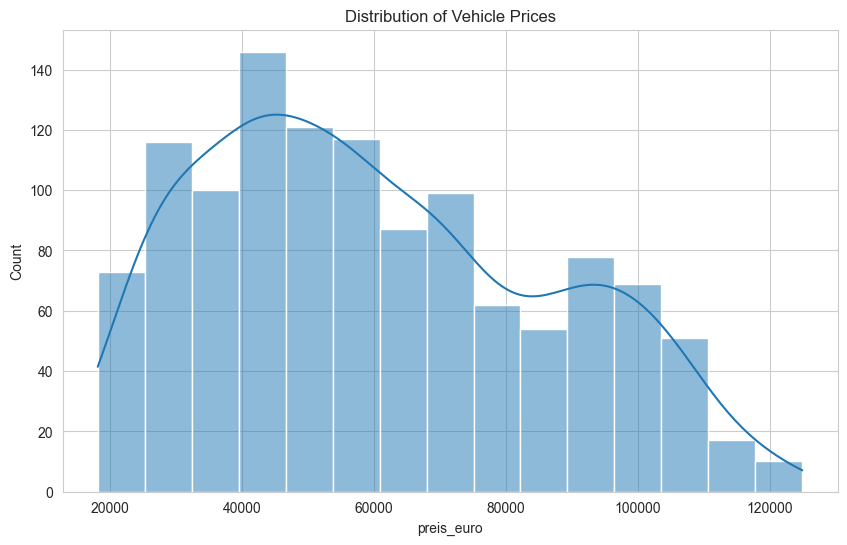

In [13]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["preis_euro"],
    kde=True
)

plt.title(
    "Distribution of Vehicle Prices"
)

plt.show()

Wichtigste Erkenntnisse:  
Schiefe (Skewness): Das Diagramm ist rechtsschief (positiv schief). Dies ist typisch für den Automarkt: Es gibt viele Fahrzeuge im mittleren Preissegment (30.000 – 60.000 Euro), aber je höher der Preis steigt (Richtung 120.000 Euro), desto weniger Autos gibt es.

Spitzenwerte (Modus): Der Hauptpeak liegt bei ca. 40.000 – 45.000 Euro (über 140 Fahrzeuge). Es gibt jedoch einen zweiten, kleineren Peak bei etwa 95.000 Euro. Dies deutet auf zwei verschiedene Marktsegmente hin (z. B. Standard- vs. Premium-Fahrzeuge).

5.2 Verkaufszahlen

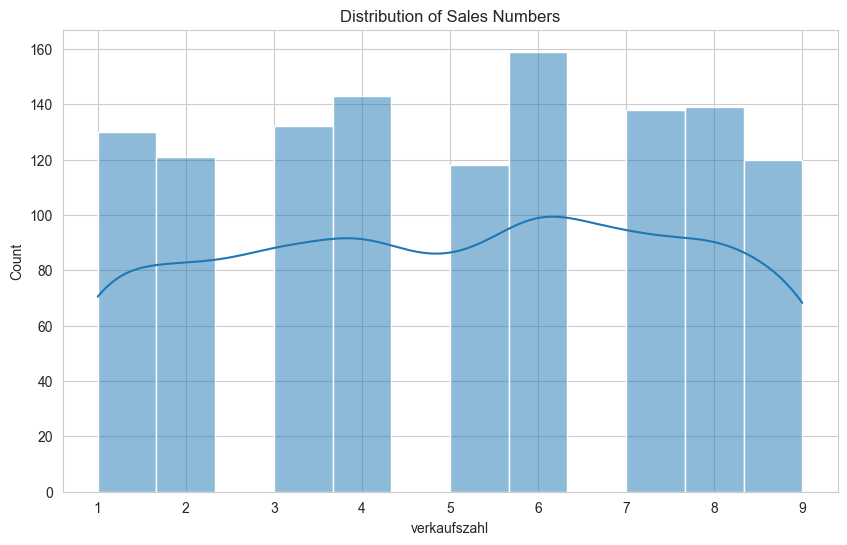

In [14]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["verkaufszahl"],
    kde=True
)

plt.title(
    "Distribution of Sales Numbers"
)

plt.show()

Wichtigste Erkenntnisse:  
Gleichmäßige Verteilung: Insgesamt sind die Daten relativ gleichmäßig verteilt (Gleichverteilung). Es gibt keine extremen Ausreißer oder starken Verzerrungen zu einer Seite.

Spitzenwerte (Modus): Der häufigste Wert ist die 6 mit fast 160 Nennungen. Der zweithäufigste Wert ist die 4 (ca. 143 Mal).

Die geglättete Linie (KDE): Die blaue Kurve zeigt den allgemeinen Trend. Sie verdeutlicht, dass das Niveau über den gesamten Bereich von 1 bis 9 recht stabil bleibt, mit einem leichten Hochpunkt um den Wert 6 herum.

5.3 Kundenzufriedenheit

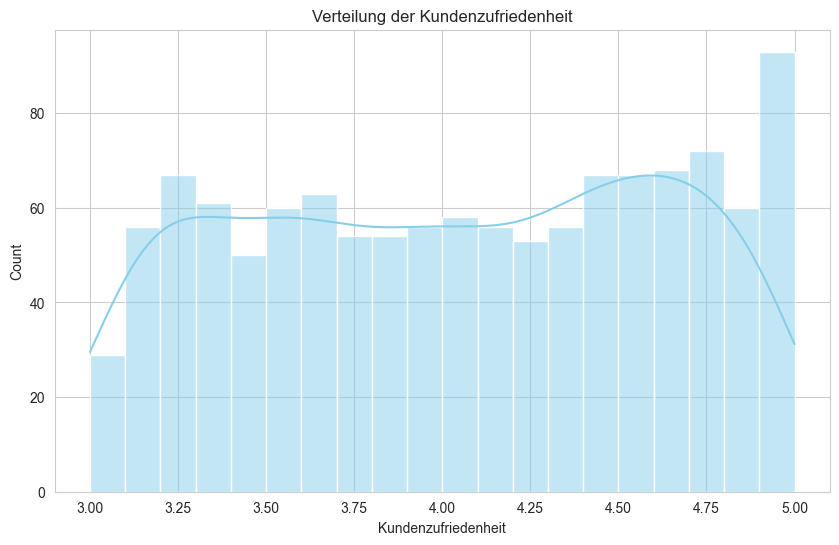

In [45]:
plt.figure(figsize=(10, 6))

sns.histplot(df["kundenzufriedenheit"], kde=True, binwidth=0.1, color="skyblue")

plt.title("Verteilung der Kundenzufriedenheit")
plt.xlabel("Kundenzufriedenheit")
plt.ylabel("Count")
plt.show()

Wichtigste Erkenntnis:  
 Der absolute Spitzenwert (Modus) liegt exakt bei 5,00 (Bestbewertung). Das ist ein typisches Phänomen bei Umfragen – Kunden vergeben sehr gerne die volle Punktzahl.

Fazit für ML: Die Daten sind jetzt sauber und frei von künstlichem Rauschen. Ein ML-Modell kann nun den echten Trend lernen: Die Wahrscheinlichkeit für eine Bewertung über 4,5 ist deutlich höher als für einen Wert um 3,0.

5.4 Ausreisseranalyse

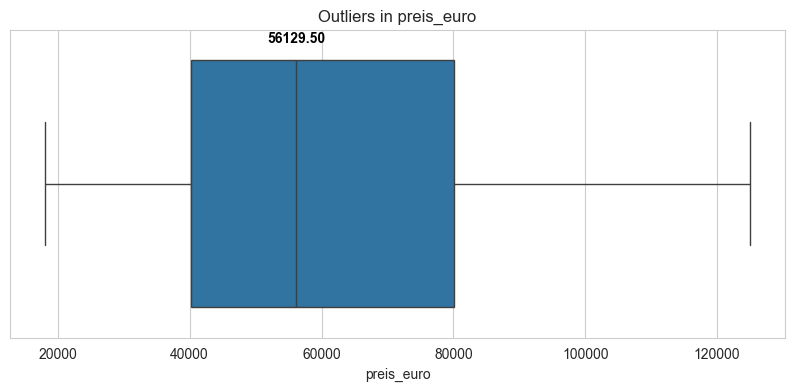

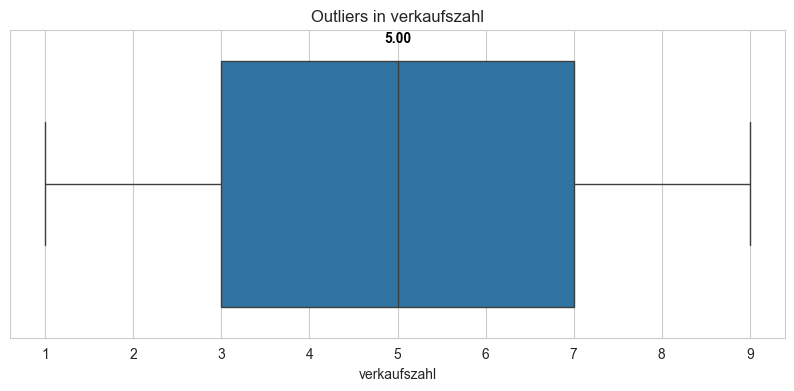

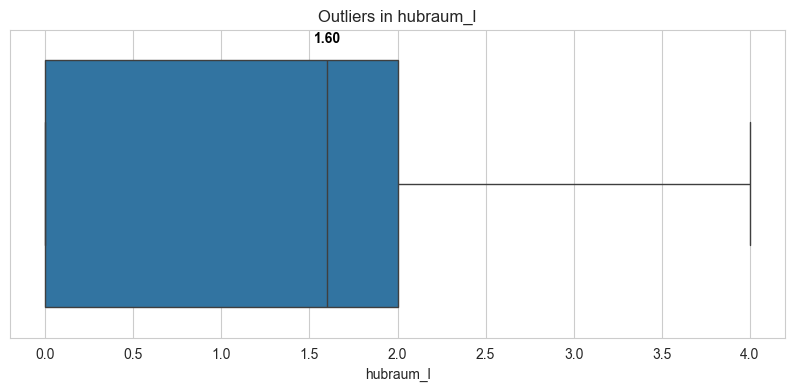

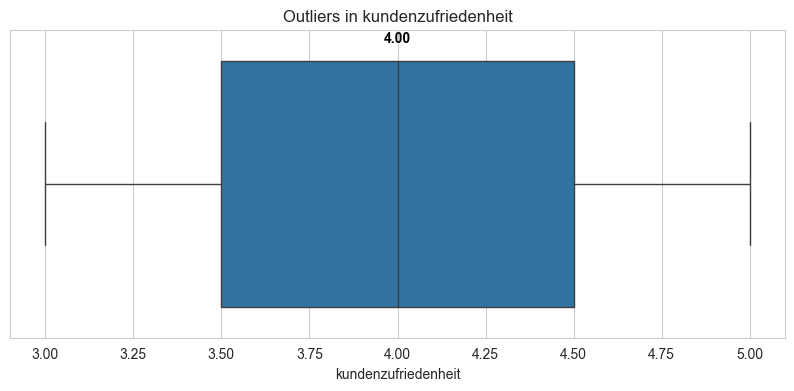

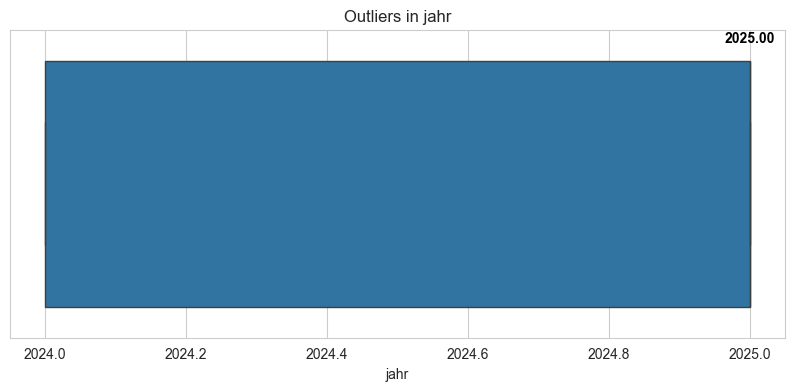

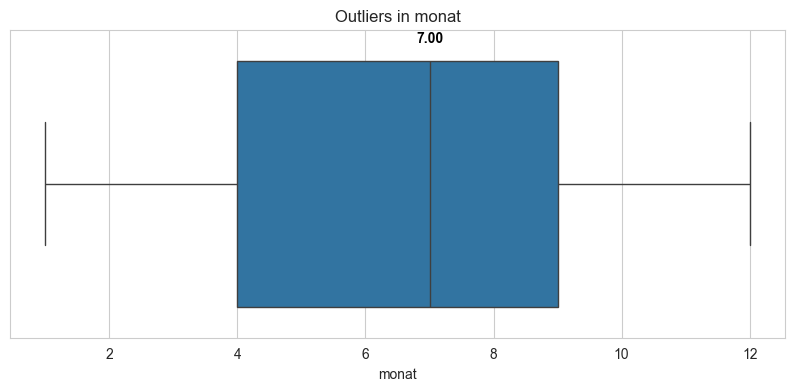

In [42]:
for column in numerical_columns:
    plt.figure(figsize=(10, 4))

    ax = sns.boxplot(x=df[column])

    median_line = ax.lines[4]
    x_coords = median_line.get_xdata()
    y_coords = median_line.get_ydata()

    median_val = x_coords[0]

    
    y_top = min(y_coords)  

    ax.text(
        x=median_val,
        y=y_top - 0.05, 
        s=f"{median_val:.2f}",
        color="black",
        weight="bold",
        ha="center",  
        va="bottom"  
    )

    plt.title(f"Outliers in {column}")
    plt.show()

6. DATA VISUALIZATION  - KATEGORISCHE ANALYSE

6.1 Marken

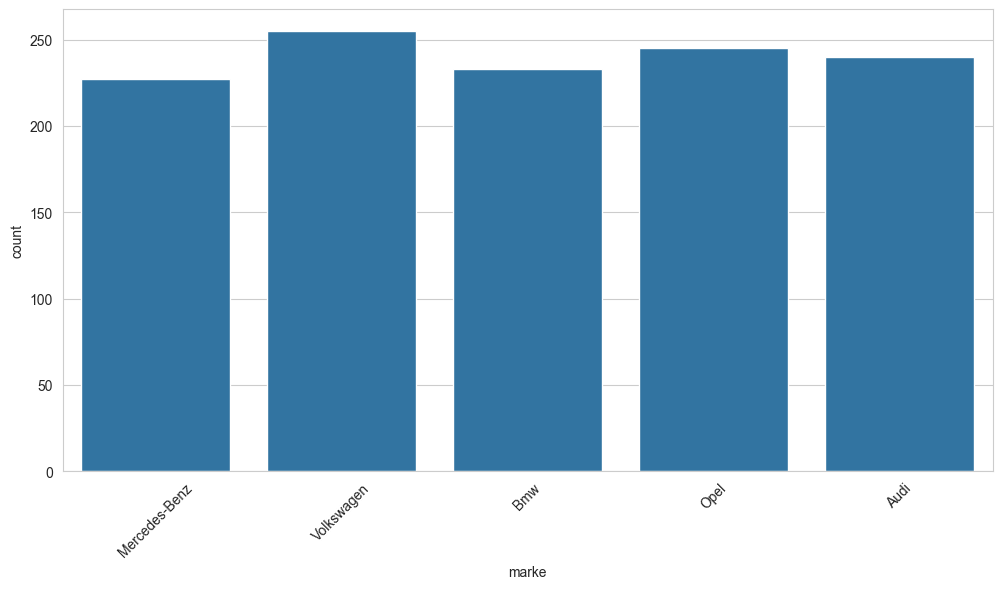

In [17]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="marke"
)

plt.xticks(rotation=45)

plt.show()

6.2 Kraftstoff

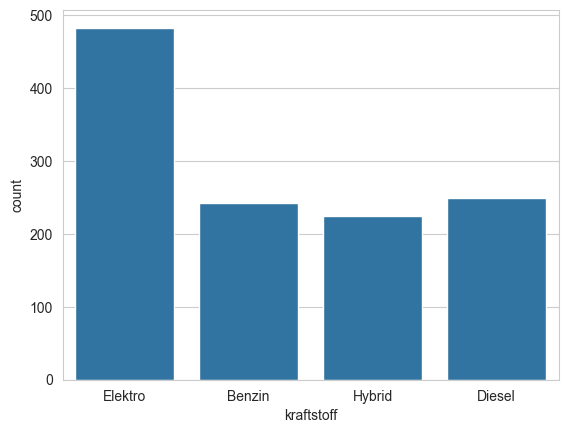

In [18]:
sns.countplot(
    data=df,
    x="kraftstoff"
)

plt.show()

6.3 Getriebe

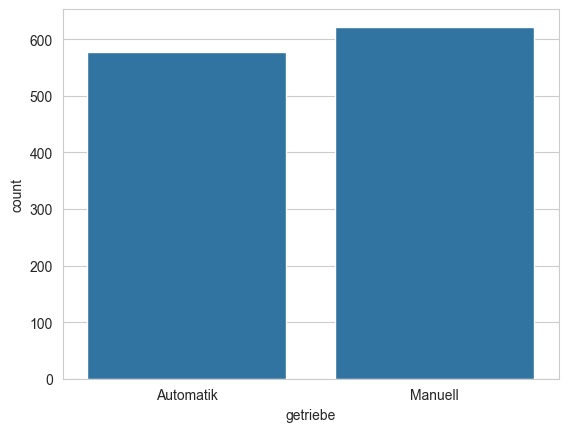

In [19]:
sns.countplot(
    data=df,
    x="getriebe"
)

plt.show()

10. EINFLUSSANALYSE

10.1 Marke → Preis

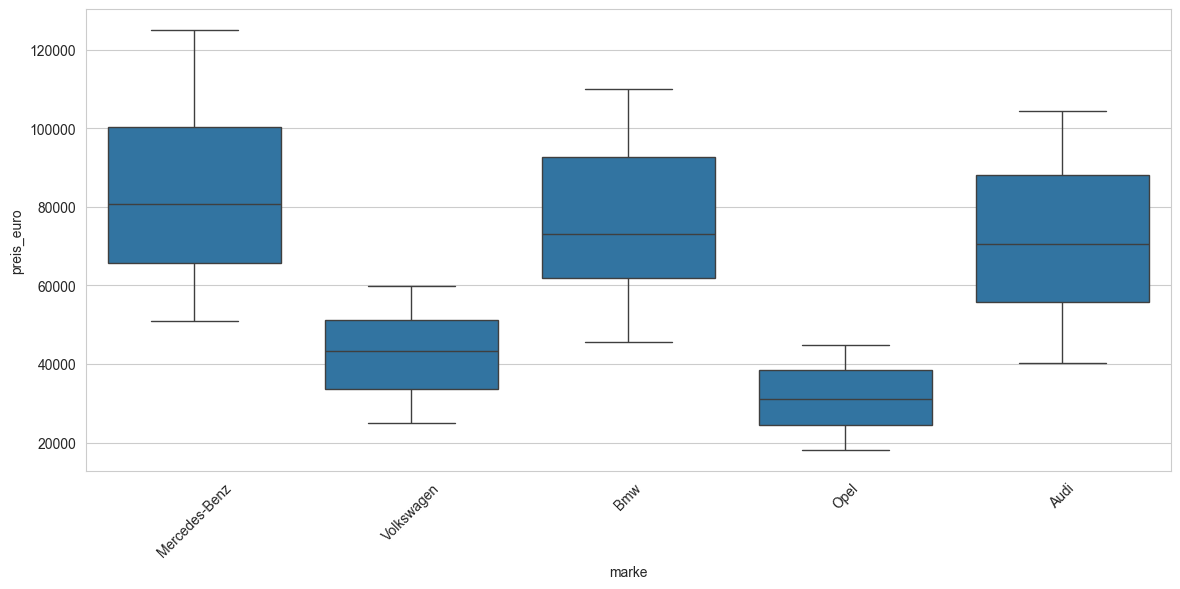

In [20]:
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df,
    x="marke",
    y="preis_euro"
)

plt.xticks(rotation=45)

plt.show()

10.2 Kraftstoff → Preis

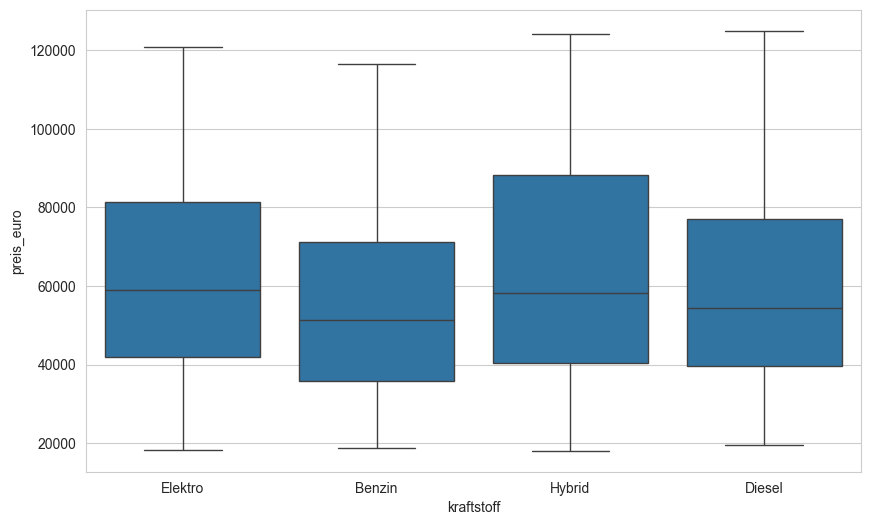

In [21]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="kraftstoff",
    y="preis_euro"
)

plt.show()

10.3 Getriebe → Preis

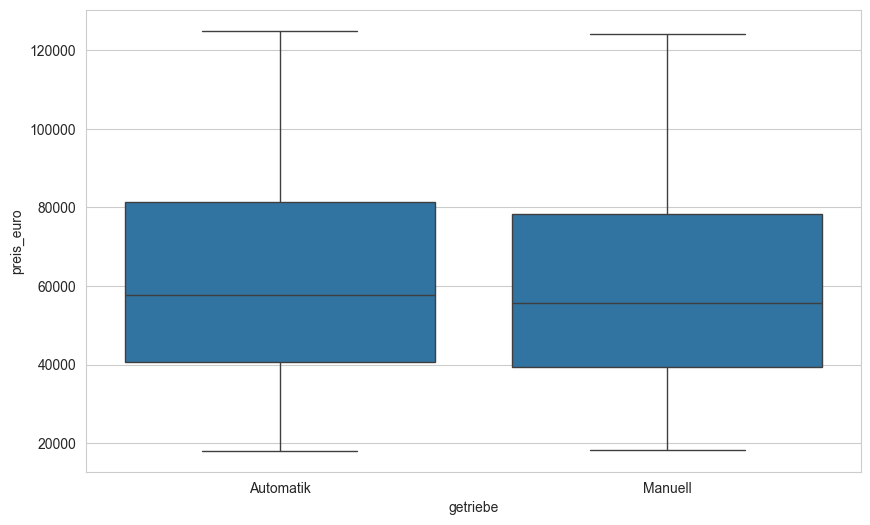

In [22]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="getriebe",
    y="preis_euro"
)

plt.show()

10.4 Hubraum → Preis

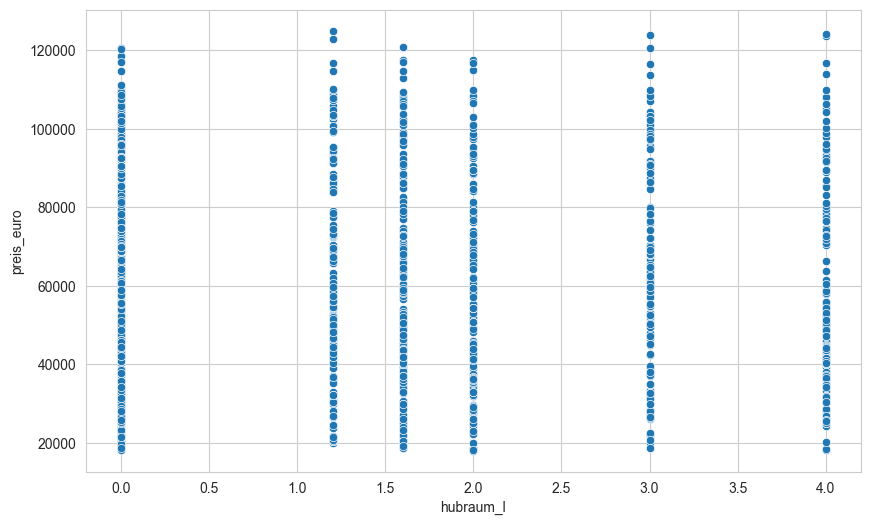

In [23]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="hubraum_l",
    y="preis_euro"
)

plt.show()

10.5 Verkaufszahl → Preis

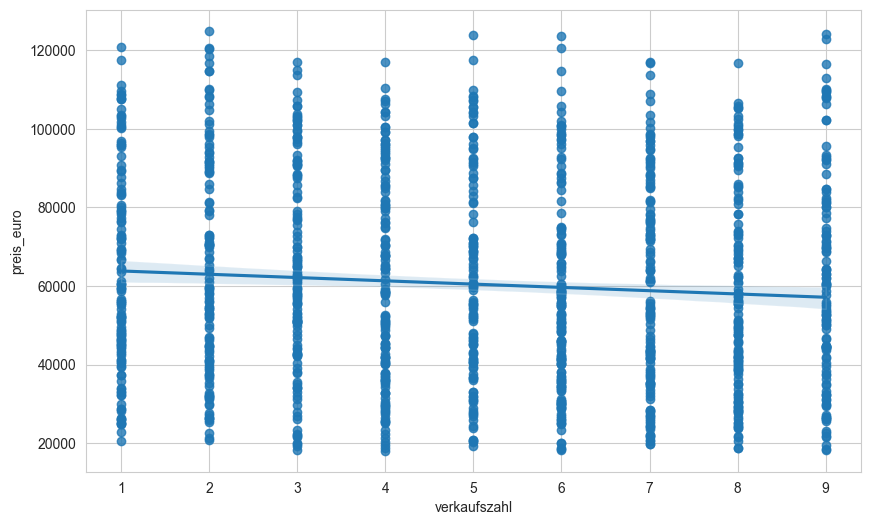

In [24]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x="verkaufszahl",
    y="preis_euro"
)

plt.show()

11. ZUSAMMENHANGSANALYSE

In [25]:
corr_matrix = (
    df[numerical_columns]
    .corr(method="pearson")
)

corr_matrix

,preis_euro,verkaufszahl,hubraum_l,kundenzufriedenheit,jahr,monat
preis_euro,1.000000,-0.081754,0.013972,0.025650,0.057965,-0.008052
verkaufszahl,-0.081754,1.000000,0.007366,-0.074914,-0.021620,-0.004276
hubraum_l,0.013972,0.007366,1.000000,-0.015391,-0.011348,-0.049634
kundenzufriedenheit,0.025650,-0.074914,-0.015391,1.000000,0.047530,0.044849
jahr,0.057965,-0.021620,-0.011348,0.047530,1.000000,-0.010622
monat,-0.008052,-0.004276,-0.049634,0.044849,-0.010622,1.000000


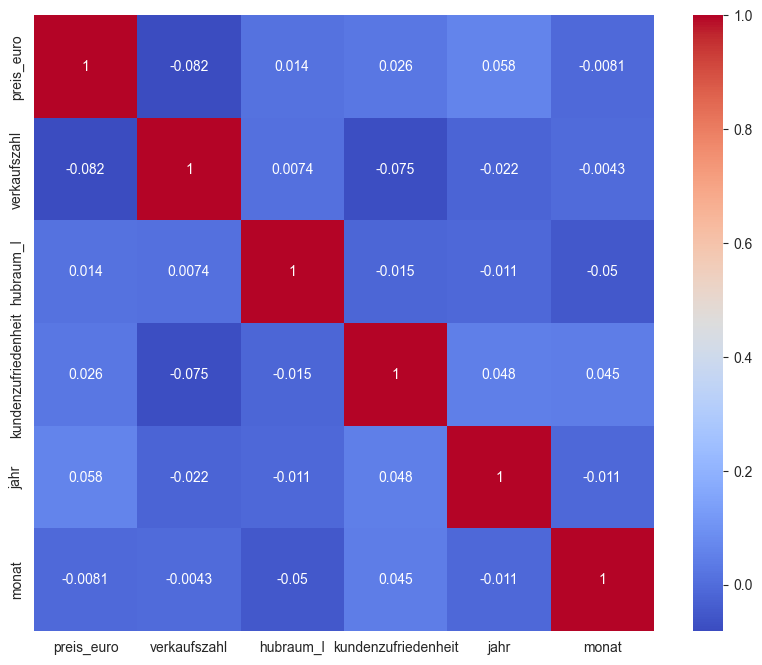

In [26]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.show()

12. HYPOTHESENTEST

H0

Der durchschnittliche Preis von Benzin- und Elektrofahrzeugen ist gleich.

In [27]:
benzin = df[
    df["kraftstoff"] == "Benzin"
]["preis_euro"]

elektro = df[
    df["kraftstoff"] == "Elektro"
]["preis_euro"]

t_stat, p_value = ttest_ind(
    benzin,
    elektro,
    equal_var=False
)

print(
    f"T-Statistic: {t_stat}"
)

print(
    f"P-Value: {p_value}"
)

T-Statistic: -3.4308102954089112
P-Value: 0.0006520137029288206


13. ANOVA

Beeinflusst das Getriebe den Preis?

In [28]:
groups = [
    group["preis_euro"].values
    for _, group
    in df.groupby("getriebe")
]

f_stat, p_value = f_oneway(
    *groups
)

print(
    f"F-Statistic: {f_stat}"
)

print(
    f"P-Value: {p_value}"
)

F-Statistic: 1.5543000341025939
P-Value: 0.21274545927914348


14. ZIELVARIABLE

Regression - target = "preis_euro"

In [29]:
target = "preis_euro"

Einflussvariablen 

In [30]:
features = [
    "marke",
    "modell",
    "verkaufszahl",
    "kraftstoff",
    "getriebe",
    "hubraum_l",
    "bundesland",
    "jahr",
    "monat",
    "wochentag"
]

X = df[features]
y = df[target]

X.head()

,marke,modell,verkaufszahl,kraftstoff,getriebe,hubraum_l,bundesland,jahr,monat,wochentag
0,Mercedes-Benz,C-Klasse,2,Elektro,Automatik,0.0,Berlin,2024,1,Monday
1,Mercedes-Benz,E-Klasse,2,Benzin,Manuell,1.2,Nrw,2024,1,Monday
2,Volkswagen,Passat,6,Hybrid,Manuell,2.0,Baden-Württemberg,2024,1,Sunday
3,Mercedes-Benz,C-Klasse,3,Diesel,Automatik,4.0,Berlin,2024,1,Sunday
4,Bmw,5Er,1,Elektro,Automatik,0.0,Berlin,2024,1,Monday


15. ERSTE SCHLUSSFOLGERUNGEN

Datenqualität
Keine fehlenden Werte
Keine Duplikate
Preisverteilung
Die Preise sind rechtsschief verteilt.
Einflussanalyse
Größere Motoren führen tendenziell zu höheren Preisen.
Kraftstoffart beeinflusst den Preis deutlich.
Einige Marken weisen deutlich höhere Durchschnittspreise auf.
Zusammenhangsanalyse
Hubraum zeigt eine positive Korrelation zum Preis.
Kundenzufriedenheit und Preis besitzen nur einen schwachen Zusammenhang.
Hypothesentest
Bei p < 0,05 wird die Nullhypothese verworfen.

In [38]:
verkaufstage = (
    df["wochentag"]
    .value_counts()
    .reset_index()
)

verkaufstage.columns = [
    "Wochentag",
    "Anzahl_Verkaeufe"
]

verkaufstage

,Wochentag,Anzahl_Verkaeufe
0,Monday,196
1,Sunday,191
2,Wednesday,177
3,Saturday,168
4,Thursday,160
5,Tuesday,159
6,Friday,149


In [35]:
df["preis_euro"].describe()

count      1200.000000
mean      60453.470833
std       25948.390215
min       18086.000000
25%       40274.000000
50%       56129.500000
75%       80027.500000
max      124965.000000
Name: preis_euro, dtype: float64

In [36]:
df["preis_euro"].skew()

np.float64(0.39752956110953036)

Welche Faktoren beeinflussen den Verkaufspreis und die Verkaufszahlen von Autos in Deutschland?  
Definition der Zielvariable  
-a  preis_euro  
- b verkaufszahl  
Beschreibung des Anwendungsbereichs  
Die Analyse kann von Autohändlern verwendet werden, um Fahrzeugpreise besser einzuschätzen und Verkaufsstrategien zu optimieren.  

Berechnung von Lageparametern  
Mittelwert  
Median  
Quartile  
 



durchschnitt - 60453. 470
min 18086
max 124965

median - 56129.5

Berechnung von Streuungsmaßen  
Standardabweichung   SELECT
    STDDEV(preis_euro) AS std_preis,
    VARIANCE(preis_euro) AS var_preis
FROM sales;  std.price -  25948.39


Varianz   
var_pr - 673318954.73

Analyse der Verteilungen der Variablen  

Histogramm von preis_euro
Boxplot
Verteilung nach Marke

<Axes: xlabel='preis_euro', ylabel='Count'>

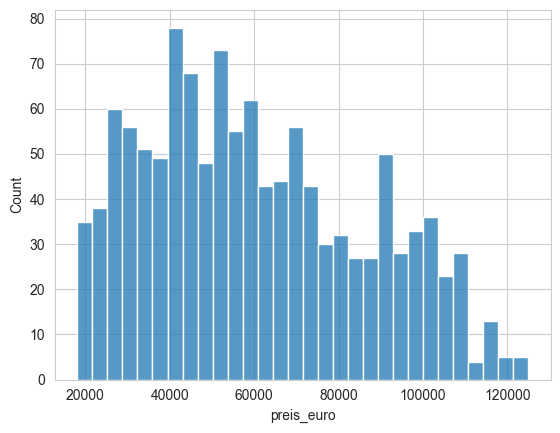

In [32]:
sns.histplot(df['preis_euro'], bins=30)

Bewertung der Datenqualität  
есть ли пропуски
есть ли дубликаты
реалистичные ли цены
есть ли ошибки

Erstellung geeigneter Visualisierungen  
Histogramm

Цена автомобилей

Boxplot

Цена по маркам

Heatmap

Корреляции

Scatterplot

Hubraum vs Preis

Auswahl geeigneter Verfahren  

Ziel	Methode
Zusammenhang	Korrelation
Preisvorhersage	Regression
Gruppenvergleich	ANOVA
Mittelwertvergleich	t-Test

Formulierung statistischer Hypothesen  
H0:

Die Getriebeart hat keinen Einfluss auf den Preis.
H1:

Die Getriebeart beeinflusst den Preis.  

In [33]:
import sys
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score

import torch
import torch.nn as nn
import torch.optim as optim

from db.data_loader import load_data


# ==================================================
# 1. LOAD DATA
# ==================================================

df = load_data()

# clean
df["marke"] = df["marke"].astype(str).str.upper()
df["modell"] = df["modell"].astype(str).str.upper()

# target
y = df["preis_euro"].values

# features
cat_cols = ["marke", "modell", "kraftstoff", "getriebe", "bundesland"]
num_cols = ["hubraum_l", "kundenzufriedenheit", "jahr"]

# encode categorical
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le


X_cat = df[cat_cols].values
X_num = df[num_cols].values

scaler = StandardScaler()
X_num = scaler.fit_transform(X_num)

X = np.hstack([X_cat, X_num])


# ==================================================
# 2. TRAIN TEST SPLIT
# ==================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)


# ==================================================
# 3. MODEL (MLP)
# ==================================================

class PriceNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)


model = PriceNet(X_train.shape[1])

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


# ==================================================
# 4. TRAIN
# ==================================================

epochs = 200

for epoch in range(epochs):
    model.train()

    optimizer.zero_grad()
    outputs = model(X_train)

    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.2f}")


# ==================================================
# 5. EVALUATION
# ==================================================

model.eval()
with torch.no_grad():
    preds = model(X_test).numpy().flatten()

mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print("\n========== DEEP LEARNING RESULTS ==========")
print(f"MAE : {mae:.2f} €")
print(f"R²   : {r2:.4f}")

Epoch 0, Loss: 4426803200.00
Epoch 20, Loss: 4425958912.00
Epoch 40, Loss: 4424143360.00
Epoch 60, Loss: 4420145664.00
Epoch 80, Loss: 4412079616.00
Epoch 100, Loss: 4397386752.00
Epoch 120, Loss: 4372982784.00
Epoch 140, Loss: 4335612928.00
Epoch 160, Loss: 4282326528.00
Epoch 180, Loss: 4211001088.00

========== DEEP LEARNING RESULTS ==========
MAE : 54132.06 €
R²   : -4.3752
